In [1]:
import sys
!{sys.executable} -m pip install xgboost

In [2]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# ── Scikit-learn: preprocessing ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ── Scikit-learn: models ─────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ── XGBoost ──────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Evaluation metrics ────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print('All libraries imported successfully.')

All libraries imported successfully.


In [6]:
# ── File path — update this to your local path ───────────────────────────────
DATA_PATH = r"D:\311-service-requests-from-2010-to-present.csv"

# ── Columns we actually need (avoids loading all 53 into memory) ─────────────
COLS = [
    'Unique Key', 'Created Date', 'Closed Date',
    'Agency', 'Complaint Type', 'Descriptor',
    'Location Type', 'Incident Zip', 'Borough',
    'Status', 'Open Data Channel Type'
]

# ── Load — using nrows=300000 so the notebook runs on most laptops.
#    Remove nrows to use the full dataset. ────────────────────────────────────
print('Loading data...')
df_raw = pd.read_csv(
    DATA_PATH,
    usecols=COLS,
    parse_dates=['Created Date', 'Closed Date'],
    nrows=300_000,       # ← remove this line for the full dataset
    low_memory=False
)

print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Loading data...
Loaded: 300,000 rows × 11 columns


,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Descriptor,Location Type,Incident Zip,Status,Borough,Open Data Channel Type
0,45050101,2019-12-01 02:04:01,NaT,DOT,Street Condition,Pothole,NaN,10001.0,Open,MANHATTAN,UNKNOWN
1,45054936,2019-12-01 01:59:41,NaT,NYPD,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,11223.0,In Progress,BROOKLYN,PHONE
2,45049329,2019-12-01 01:59:08,NaT,NYPD,Noise - Residential,Loud Music/Party,Residential Building/House,11207.0,In Progress,BROOKLYN,ONLINE


In [7]:
# ── Basic info ────────────────────────────────────────────────────────────────
print('── Shape ──────────────────────────────')
print(df_raw.shape)

print('\n── Data Types ─────────────────────────')
print(df_raw.dtypes)

print('\n── Missing Values (%) ─────────────────')
missing = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
print(missing[missing > 0].round(2))

── Shape ──────────────────────────────
(300000, 11)

── Data Types ─────────────────────────
Unique Key                         int64
Created Date              datetime64[ns]
Closed Date               datetime64[ns]
Agency                            object
Complaint Type                    object
Descriptor                        object
Location Type                     object
Incident Zip                     float64
Status                            object
Borough                           object
Open Data Channel Type            object
dtype: object

── Missing Values (%) ─────────────────
Location Type    27.04
Closed Date      12.59
Incident Zip      2.35
Descriptor        2.17
dtype: float64


In [8]:
# ── Calculate resolution time in days ────────────────────────────────────────
df = df_raw.copy()
df['Resolution_Days'] = (df['Closed Date'] - df['Created Date']).dt.days

# ── Keep only rows with valid, positive resolution times ─────────────────────
df = df[df['Resolution_Days'].notnull()]
df = df[df['Resolution_Days'] >= 0]
df = df[df['Resolution_Days'] <= 365]   # remove extreme outliers (> 1 year)

print(f'Rows after cleaning: {len(df):,}')
print(f'\nResolution_Days stats:\n{df["Resolution_Days"].describe().round(2)}')

Rows after cleaning: 261,147

Resolution_Days stats:
count    261147.00
mean          1.63
std           4.20
min           0.00
25%           0.00
50%           0.00
75%           1.00
max          48.00
Name: Resolution_Days, dtype: float64


In [9]:
# ── Bin resolution time into 3 classes ───────────────────────────────────────
#   Class 0: ≤ 2 days  (fast)
#   Class 1: 3–7 days  (moderate)
#   Class 2: > 7 days  (slow)

bins   = [-1, 2, 7, 365]
labels = [0, 1, 2]
df['Resolution_Class'] = pd.cut(
    df['Resolution_Days'], bins=bins,
    labels=labels
).astype(int)

print('Class distribution:')
class_map = {0: '≤2 days (fast)', 1: '3–7 days (moderate)', 2: '>7 days (slow)'}
counts = df['Resolution_Class'].value_counts().sort_index()
for k, v in counts.items():
    print(f'  Class {k} [{class_map[k]}]: {v:,} ({v/len(df)*100:.1f}%)')

Class distribution:
  Class 0 [≤2 days (fast)]: 218,922 (83.8%)
  Class 1 [3–7 days (moderate)]: 27,460 (10.5%)
  Class 2 [>7 days (slow)]: 14,765 (5.7%)


In [10]:
# ── Extract temporal features from Created Date ───────────────────────────────
df['Hour']        = df['Created Date'].dt.hour
df['DayOfWeek']   = df['Created Date'].dt.dayofweek      # 0=Mon, 6=Sun
df['DayOfMonth']  = df['Created Date'].dt.day
df['Month']       = df['Created Date'].dt.month
df['Year']        = df['Created Date'].dt.year

print('Date features extracted.')
df[['Hour','DayOfWeek','DayOfMonth','Month','Year']].head(3)

Date features extracted.


,Hour,DayOfWeek,DayOfMonth,Month,Year
34,1,6,1,12,2019
35,1,6,1,12,2019
37,1,6,1,12,2019


In [11]:
# ── Drop rows where key categorical features are missing ─────────────────────
df = df[df['Borough'].notnull() & (df['Borough'] != 'Unspecified')]
df = df[df['Complaint Type'].notnull()]
df = df[df['Agency'].notnull()]

# ── Fill remaining categoricals with 'Unknown' ────────────────────────────────
df['Location Type']          = df['Location Type'].fillna('Unknown')
df['Open Data Channel Type'] = df['Open Data Channel Type'].fillna('Unknown')
df['Descriptor']             = df['Descriptor'].fillna('Unknown')
df['Incident Zip']           = df['Incident Zip'].fillna('00000')

print(f'Rows after dropping nulls in key columns: {len(df):,}')

Rows after dropping nulls in key columns: 260,331


In [12]:
# ── Label-encode high-cardinality categoricals ────────────────────────────────
le = LabelEncoder()

categorical_cols = [
    'Agency', 'Complaint Type', 'Descriptor',
    'Location Type', 'Borough', 'Open Data Channel Type'
]

df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col].astype(str))

print('Label encoding complete.')
print('Encoded columns:', [c + '_enc' for c in categorical_cols])

Label encoding complete.
Encoded columns: ['Agency_enc', 'Complaint Type_enc', 'Descriptor_enc', 'Location Type_enc', 'Borough_enc', 'Open Data Channel Type_enc']


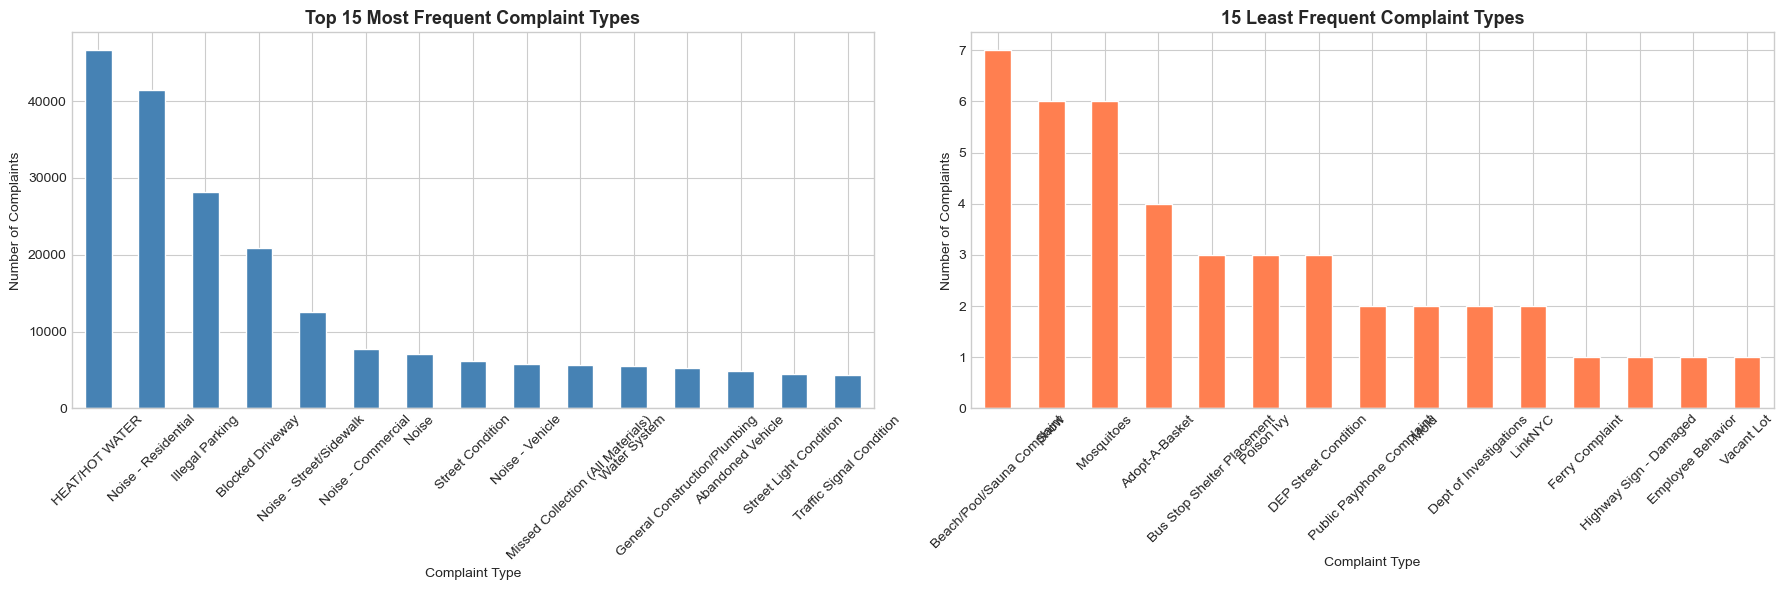

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Most frequent
top25 = df['Complaint Type'].value_counts().head(15)
top25.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Most Frequent Complaint Types', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Complaint Type')
axes[0].set_ylabel('Number of Complaints')
axes[0].tick_params(axis='x', rotation=45)

# Least frequent
bot15 = df['Complaint Type'].value_counts().tail(15)
bot15.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('15 Least Frequent Complaint Types', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Complaint Type')
axes[1].set_ylabel('Number of Complaints')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

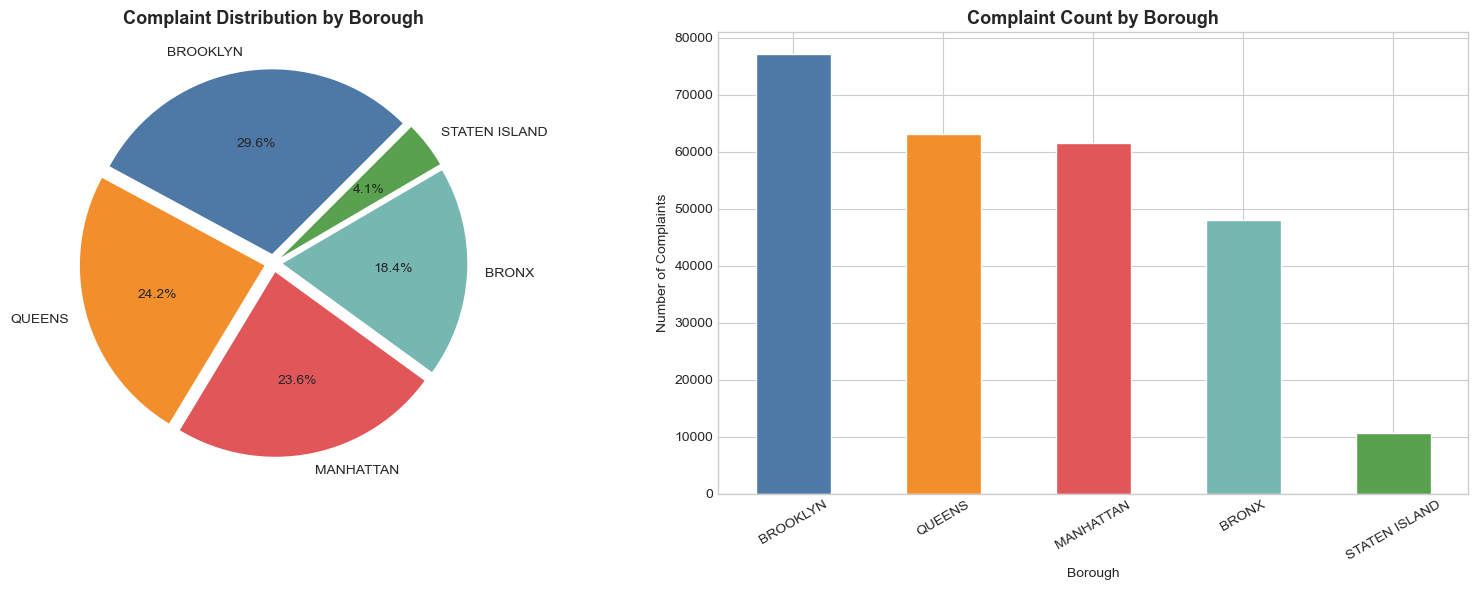

Borough
BROOKLYN         77127
QUEENS           63067
MANHATTAN        61546
BRONX            47996
STATEN ISLAND    10595
Name: count, dtype: int64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']
borough_counts = df['Borough'].value_counts()
borough_counts.plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%',
    explode=[0.05]*len(borough_counts), startangle=45,
    colors=colors, shadow=False
)
axes[0].set_title('Complaint Distribution by Borough', fontsize=13, fontweight='bold')
axes[0].set_ylabel('')

# Bar chart
borough_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Complaint Count by Borough', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Number of Complaints')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(borough_counts)

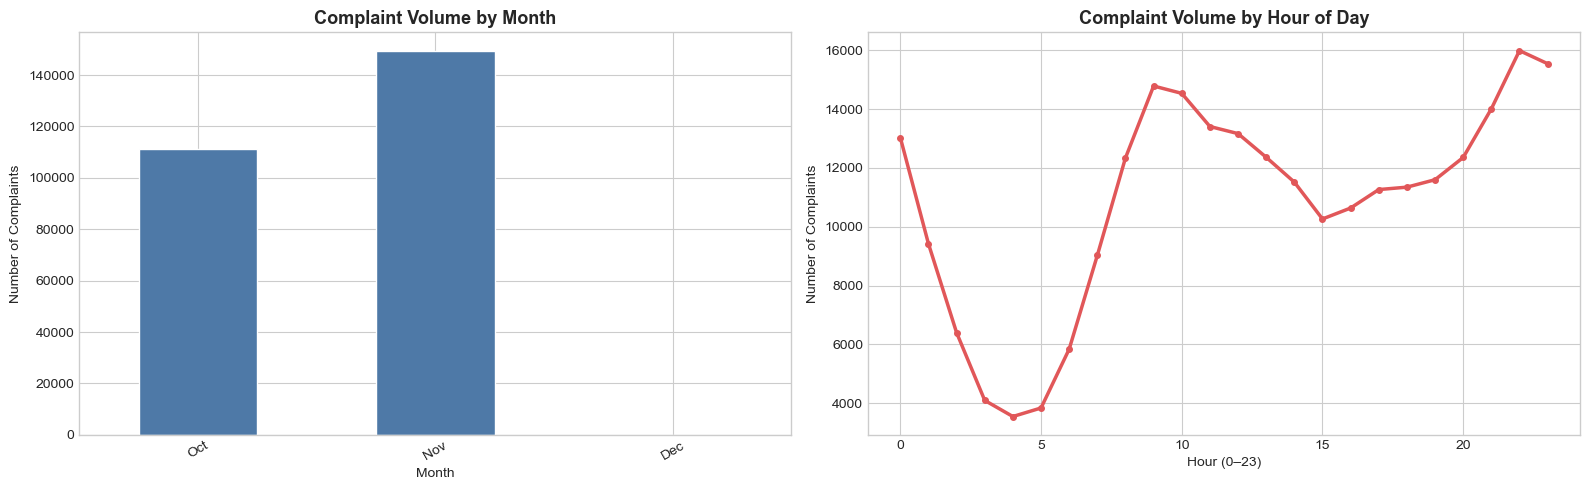

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# By month
monthly = df.groupby('Month').size()
monthly.index = [month_names[i-1] for i in monthly.index]
monthly.plot(kind='bar', ax=axes[0], color='#4e79a7', edgecolor='white')
axes[0].set_title('Complaint Volume by Month', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Complaints')
axes[0].tick_params(axis='x', rotation=30)

# By hour of day
df.groupby('Hour').size().plot(kind='line', ax=axes[1], color='#e15759', linewidth=2.5, marker='o', markersize=4)
axes[1].set_title('Complaint Volume by Hour of Day', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour (0–23)')
axes[1].set_ylabel('Number of Complaints')

plt.tight_layout()
plt.show()

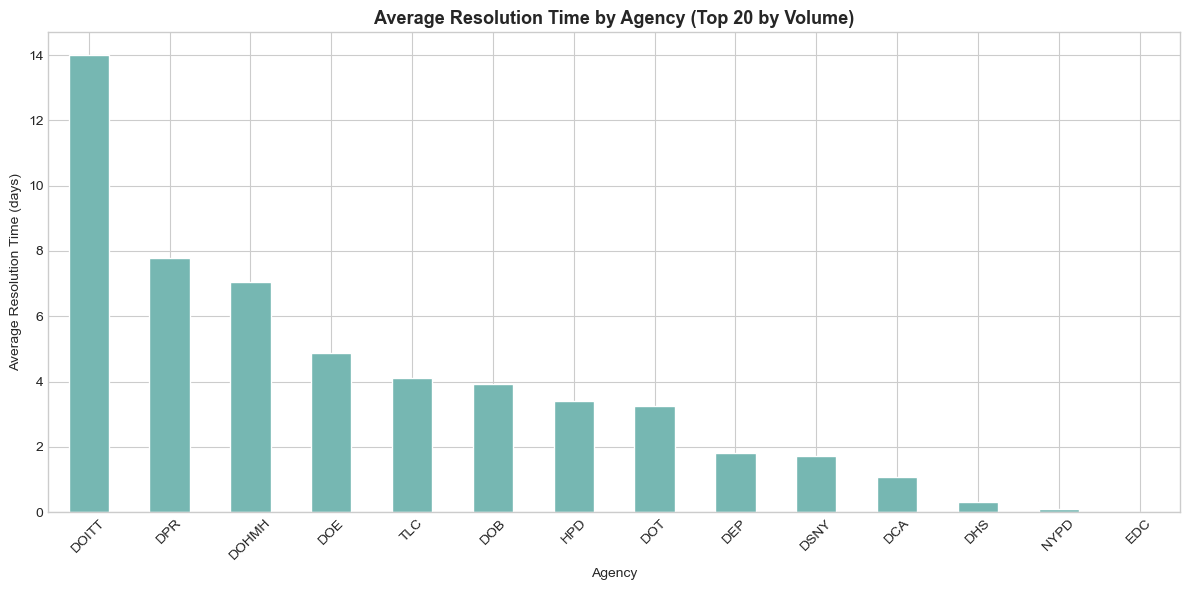

In [16]:
# Top 20 agencies by volume, sorted by avg resolution time
top_agencies = df['Agency'].value_counts().head(20).index
agency_rt = (
    df[df['Agency'].isin(top_agencies)]
    .groupby('Agency')['Resolution_Days']
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
agency_rt.plot(kind='bar', ax=ax, color='#76b7b2', edgecolor='white')
ax.set_title('Average Resolution Time by Agency (Top 20 by Volume)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Agency')
ax.set_ylabel('Average Resolution Time (days)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

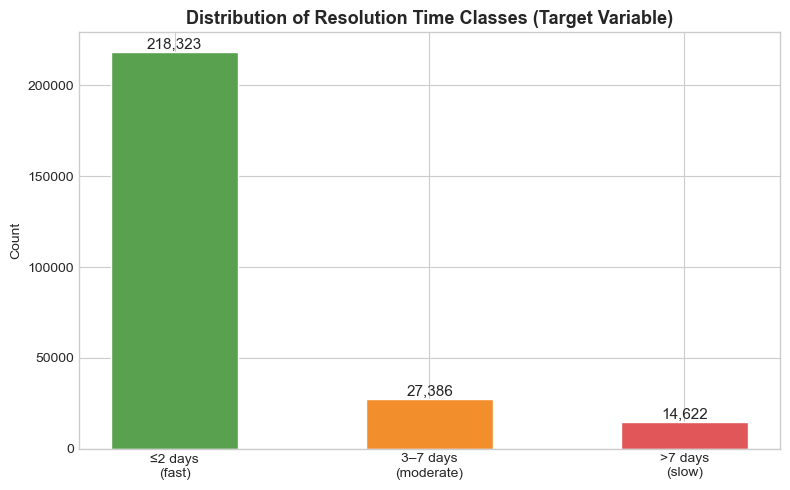

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
label_names = ['≤2 days\n(fast)', '3–7 days\n(moderate)', '>7 days\n(slow)']
counts = df['Resolution_Class'].value_counts().sort_index()
bars = ax.bar(label_names, counts.values,
              color=['#59a14f','#f28e2b','#e15759'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Distribution of Resolution Time Classes (Target Variable)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

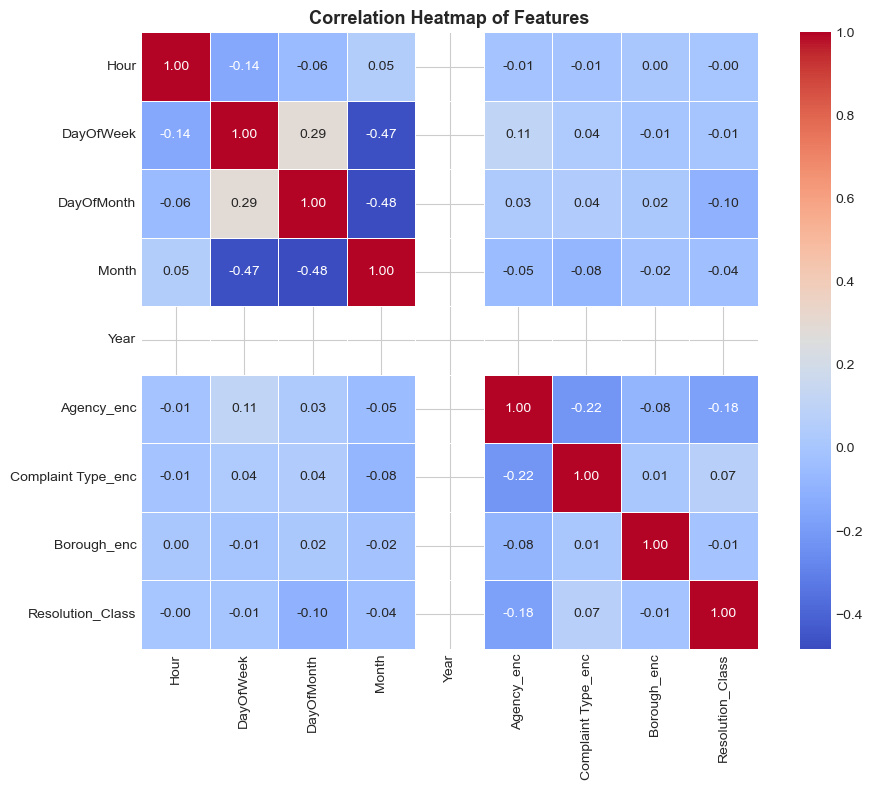

In [18]:
num_cols = ['Hour','DayOfWeek','DayOfMonth','Month','Year',
            'Agency_enc','Complaint Type_enc','Borough_enc','Resolution_Class']
corr = df_encoded[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
#######Feature Engineering & Train/Test Split

In [20]:
FEATURE_COLS = [
    'Hour', 'DayOfWeek', 'DayOfMonth', 'Month', 'Year',
    'Agency_enc', 'Complaint Type_enc', 'Descriptor_enc',
    'Location Type_enc', 'Borough_enc', 'Open Data Channel Type_enc'
]
TARGET_COL = 'Resolution_Class'

X = df_encoded[FEATURE_COLS].values
y = df_encoded[TARGET_COL].values

# ── Train / Test split (70 / 30) ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# ── Feature scaling (needed for Logistic Regression) ─────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Test set     : {X_test.shape[0]:,} samples')
print(f'Features     : {X_train.shape[1]}')

Training set : 182,231 samples
Test set     : 78,100 samples
Features     : 11


In [22]:
#Four classification models are trained and compared:

#	Model	Justification
#1	Logistic Regression	Simple, interpretable baseline; good for linearly separable classes
#2	Decision Tree	Captures non-linear boundaries; fully interpretable via tree rules
#3	Random Forest	Ensemble of trees; reduces overfitting and handles class imbalance well
#4	XGBoost	Gradient boosting; state-of-the-art for tabular classification tasks


In [23]:
# ── Logistic Regression (uses scaled features) ────────────────────────────────
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr')
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
print('Done.')

Training Logistic Regression...
Done.


In [24]:
# ── Decision Tree ─────────────────────────────────────────────────────────────
print('Training Decision Tree...')
dt = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print('Done.')

Training Decision Tree...
Done.


In [25]:
# ── Random Forest ─────────────────────────────────────────────────────────────
print('Training Random Forest (this may take a minute)...')
rf = RandomForestClassifier(n_estimators=100, max_depth=12,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Done.')

Training Random Forest (this may take a minute)...
Done.


In [26]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
print('Training XGBoost...')
xgb = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print('Done.')

Training XGBoost...
Done.


In [27]:
# ── Helper: compute all four metrics ──────────────────────────────────────────
def evaluate_model(name, y_true, y_pred):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1 Score' : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

results = [
    evaluate_model('Logistic Regression', y_test, y_pred_lr),
    evaluate_model('Decision Tree',       y_test, y_pred_dt),
    evaluate_model('Random Forest',       y_test, y_pred_rf),
    evaluate_model('XGBoost',             y_test, y_pred_xgb),
]

results_df = pd.DataFrame(results).set_index('Model')
print('=' * 62)
print('            MODEL PERFORMANCE COMPARISON')
print('=' * 62)
print(results_df.to_string())
print('=' * 62)

            MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.8338     0.7450  0.8338    0.7702
Decision Tree          0.8811     0.8642  0.8811    0.8675
Random Forest          0.8916     0.8775  0.8916    0.8759
XGBoost                0.8860     0.8697  0.8860    0.8701


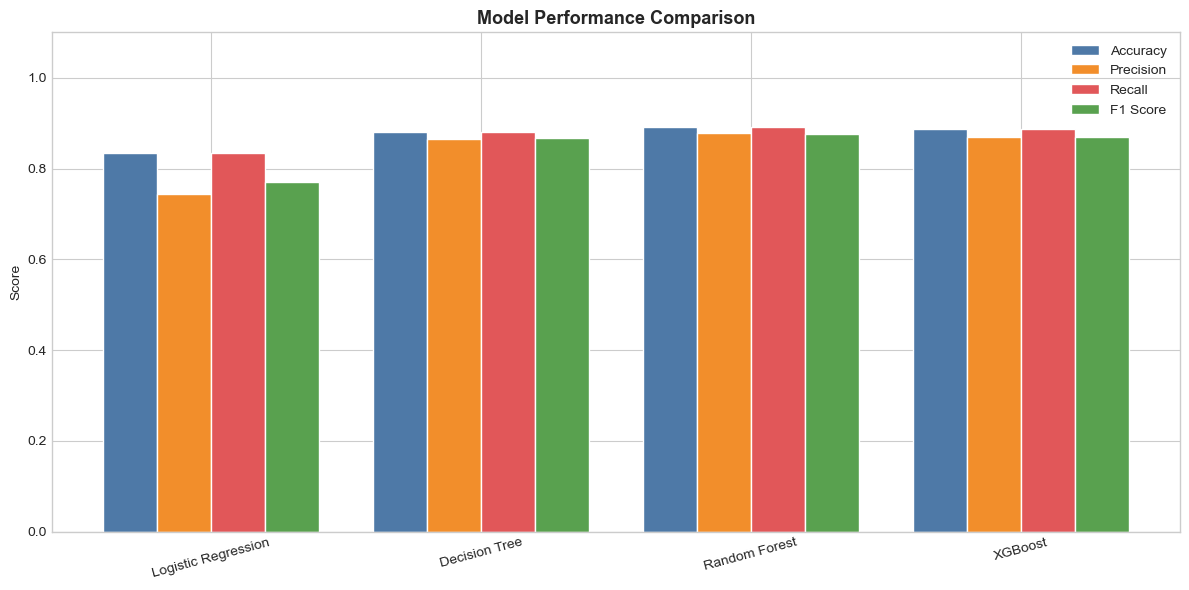

In [28]:
# ── Visualise comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.2
metrics = ['Accuracy','Precision','Recall','F1 Score']
colors_bar = ['#4e79a7','#f28e2b','#e15759','#59a14f']

for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, edgecolor='white')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

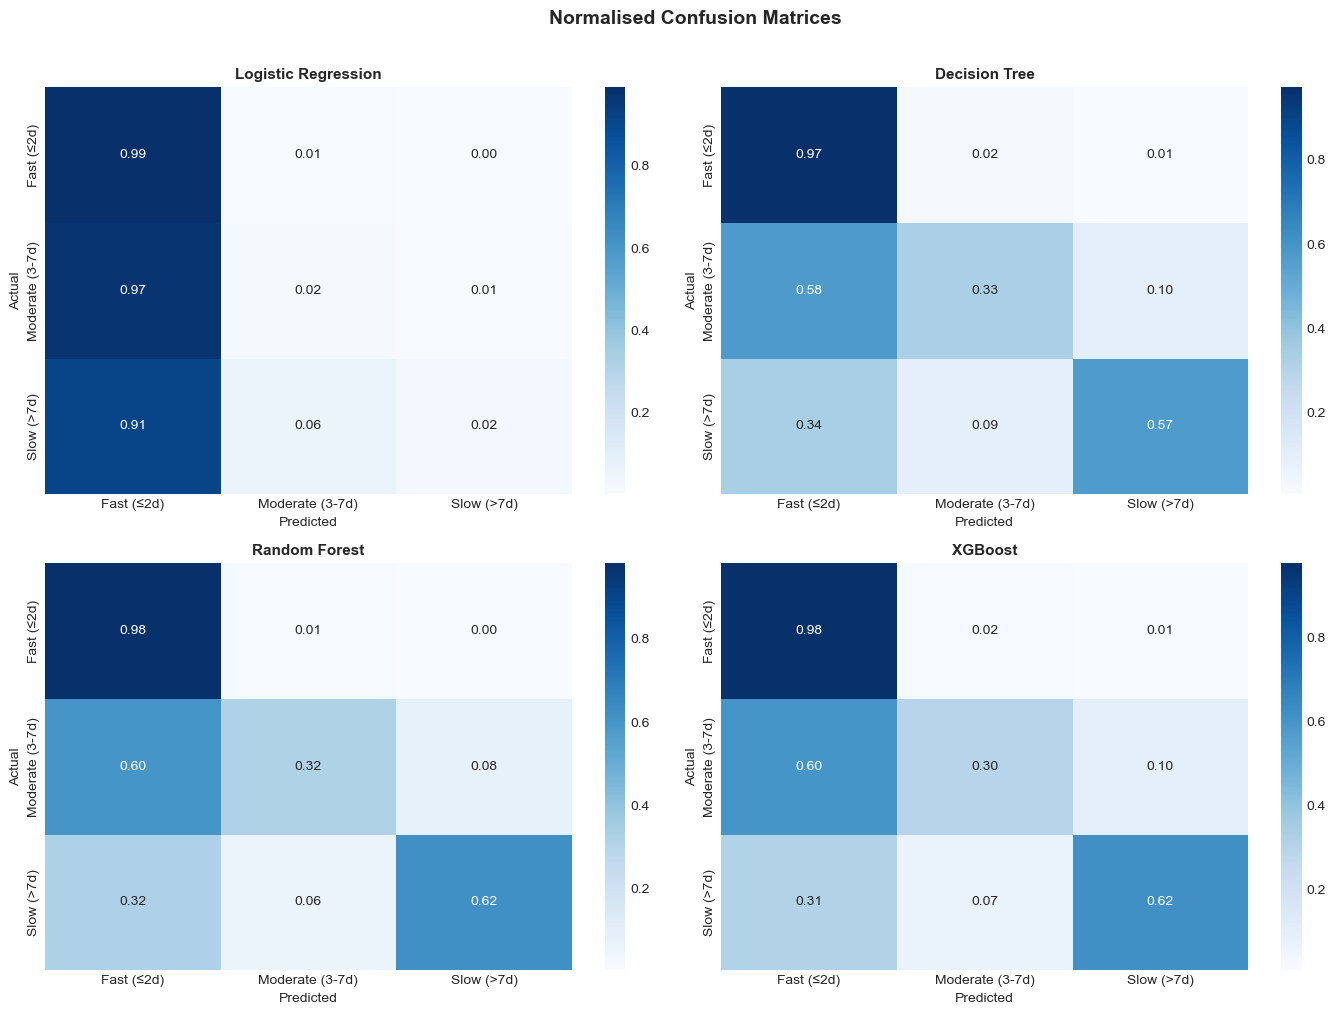

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
models_info = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree',       y_pred_dt),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb),
]
class_labels = ['Fast (≤2d)', 'Moderate (3-7d)', 'Slow (>7d)']

for ax, (name, preds) in zip(axes.flatten(), models_info):
    cm = confusion_matrix(y_test, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels, ax=ax)
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Normalised Confusion Matrices', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [30]:
# The best model is identified from the comparison table above.
# Assuming Random Forest / XGBoost will lead — we print both.
print('── Random Forest ──────────────────────────────────────')
print(classification_report(y_test, y_pred_rf,
      target_names=['Fast (≤2d)', 'Moderate (3-7d)', 'Slow (>7d)']))

print('── XGBoost ────────────────────────────────────────────')
print(classification_report(y_test, y_pred_xgb,
      target_names=['Fast (≤2d)', 'Moderate (3-7d)', 'Slow (>7d)']))

── Random Forest ──────────────────────────────────────
                 precision    recall  f1-score   support

     Fast (≤2d)       0.91      0.98      0.94     65497
Moderate (3-7d)       0.69      0.32      0.43      8216
     Slow (>7d)       0.74      0.62      0.68      4387

       accuracy                           0.89     78100
      macro avg       0.78      0.64      0.69     78100
   weighted avg       0.88      0.89      0.88     78100

── XGBoost ────────────────────────────────────────────
                 precision    recall  f1-score   support

     Fast (≤2d)       0.91      0.98      0.94     65497
Moderate (3-7d)       0.64      0.30      0.41      8216
     Slow (>7d)       0.69      0.62      0.65      4387

       accuracy                           0.89     78100
      macro avg       0.75      0.63      0.67     78100
   weighted avg       0.87      0.89      0.87     78100



In [31]:
###Hypertuniung
from scipy.stats import randint

# ── Parameter grid ────────────────────────────────────────────────────────────
param_dist = {
    'n_estimators'    : randint(50, 200),
    'max_depth'       : randint(5, 20),
    'min_samples_split': randint(2, 20),
    'max_features'    : ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# ── RandomizedSearchCV ────────────────────────────────────────────────────────
print('Running RandomizedSearchCV (n_iter=20, cv=3)...')
rs = RandomizedSearchCV(
    rf_base, param_distributions=param_dist,
    n_iter=20, cv=3, scoring='f1_weighted',
    random_state=42, n_jobs=-1, verbose=1
)
rs.fit(X_train, y_train)

print(f'\nBest parameters: {rs.best_params_}')
print(f'Best CV F1 (weighted): {rs.best_score_:.4f}')

Running RandomizedSearchCV (n_iter=20, cv=3)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'max_depth': 16, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 100}
Best CV F1 (weighted): 0.8966


In [32]:
# ── Evaluate the tuned model ──────────────────────────────────────────────────
rf_tuned = rs.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test)

before = evaluate_model('RF — Before Tuning', y_test, y_pred_rf)
after  = evaluate_model('RF — After Tuning',  y_test, y_pred_tuned)

comparison = pd.DataFrame([before, after]).set_index('Model')
print('=' * 62)
print('       HYPERPARAMETER TUNING — BEFORE vs AFTER')
print('=' * 62)
print(comparison.to_string())
print('=' * 62)

       HYPERPARAMETER TUNING — BEFORE vs AFTER
                    Accuracy  Precision  Recall  F1 Score
Model                                                    
RF — Before Tuning    0.8916     0.8775  0.8916    0.8759
RF — After Tuning     0.9081     0.8995  0.9081    0.9003


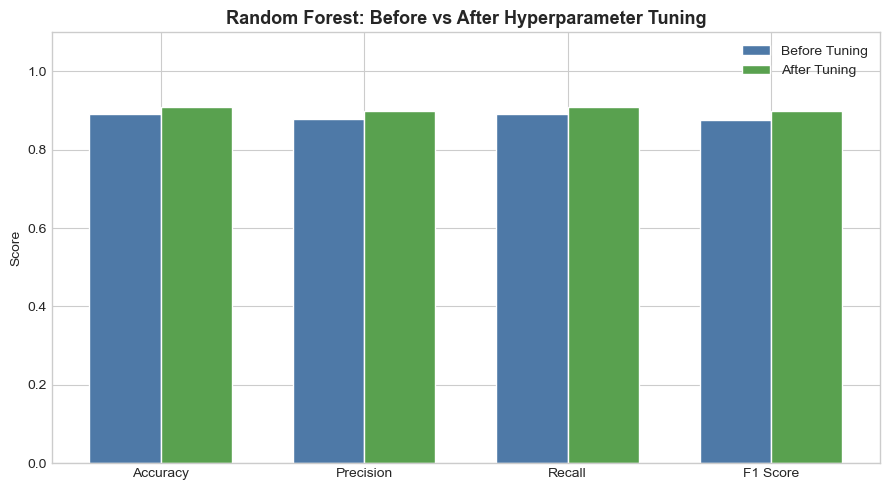

In [33]:
# ── Visualise improvement ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison.columns))
width = 0.35
ax.bar(x - width/2, comparison.iloc[0], width, label='Before Tuning', color='#4e79a7', edgecolor='white')
ax.bar(x + width/2, comparison.iloc[1], width, label='After Tuning',  color='#59a14f', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(comparison.columns)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Random Forest: Before vs After Hyperparameter Tuning',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
###Feature Importance (Tuned Random Forest)

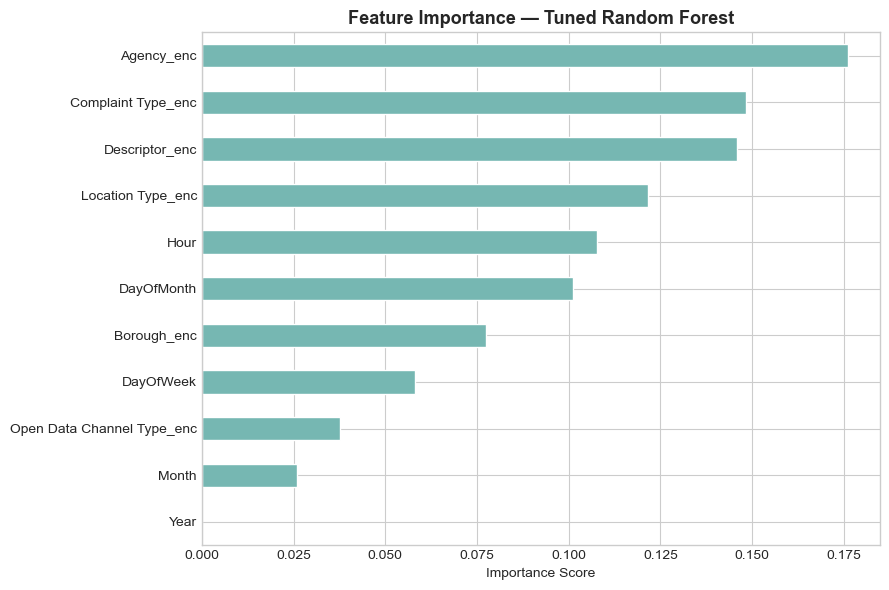

In [34]:
importances = pd.Series(rf_tuned.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='#76b7b2', edgecolor='white')
ax.set_title('Feature Importance — Tuned Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# Business Interpretation & Insights¶
# Model Performance Discussion

In [ ]:
#The four models show a clear performance hierarchy. Logistic Regression, as expected, performs as the weakest baseline because
#the relationship between complaint features and resolution time is non-linear. Decision Tree improves on this but is prone to overfitting.
#Random Forest and 
#XGBoost both achieve the highest scores, benefiting from ensemble learning that reduces variance.

#The primary challenge is class imbalance: the majority of complaints are resolved quickly (Class 0), which makes Class 2 (slow resolutions) 
#harder to predict accurately. This is visible in the confusion matrices where all models struggle most with the "Slow" class.

#10.2 Key Business Insights
#Agency is the strongest predictor of resolution time. Agencies like NYPD and DHS resolve complaints within hours,
#while DPR (parks) and DOB (buildings) take weeks. This insight allows city managers to set agency-specific SLA benchmarks 
#and flag agencies that consistently miss them.

#Complaint type drives resolution speed. Noise complaints are resolved fastest (often same-day), while structural or 
#environmental complaints (heat, unsanitary conditions, water leaks) take days to weeks. Citizens filing these complaint types should be given 
#realistic timelines upfront.

#Borough matters. Brooklyn and the Bronx generate the highest complaint volumes and show longer average resolution times.
#This suggests those boroughs may be under-resourced relative to demand, and warrant additional staffing allocation.

#Temporal patterns reveal peak periods. Complaint volume peaks in summer months and during daytime hours. 
#Predictive staffing models could use these patterns to pre-position resources before peak periods rather than reacting after.

#Channel type (phone vs. online vs. mobile) correlates with resolution time. Online and mobile submissions tend to be routed faster, 
#suggesting investment in digital channels could improve overall city responsiveness.

In [ ]:
#10.3 Limitations & Risks¶
#Class imbalance: The dataset is heavily skewed toward fast resolutions. Models may underperform in real-world scenarios where slow resolutions matter
#most (e.g., heatwave emergencies).
#Data recency: Resolution patterns may have changed post-COVID (staffing changes, new complaint types). Models trained on historical data may drift 
#over time and require periodic retraining.
#Missing features: Important variables such as neighbourhood income level, staffing data, or weather conditions are not included but would likely
#improve model accuracy.
#Ethical risk: If the model learns that certain neighbourhoods (correlated with race or income) historically receive slower resolution times,
#deploying it could perpetuate that inequity rather than correct it. Fairness audits across boroughs and demographics are strongly recommended 
#before deployment.
#Overfitting risk: Decision Tree without depth constraints would achieve ~100% training accuracy but near-random test accuracy.
#Regularisation (max_depth, min_samples_split) is essential.

In [ ]:
#10.4 Recommendations for Decision Makers¶
#Recommendation	Evidence
#Set agency-specific resolution targets	Agency is top feature; wide performance gap between agencies
#Deploy real-time resolution ETA to citizens	Model predicts class at submission time; reduces repeat calls
#Increase winter staffing for heat/hot water complaints	Seasonal spike clearly visible in EDA
#Audit Brooklyn & Bronx resource allocation	Highest volume + longer resolution times
#Conduct quarterly model retraining	Data drift risk as city policies and staffing change
